# Parte 2 — Memória temporal: Trilha A (RNN como modelo de movimento)

A fonte de detecções fica **congelada** (SDP público, score ≥ 0,9, escolhido na Parte 1), assim como o split por sequência e a família de regras de associação (IoU entre a caixa da track e as detecções, matching, nascimento, coasting e morte). O que muda é o que acontece **entre** os quadros: a caixa com que cada track concorre pelas detecções deixa de ser a última observada e passa a ser a **prevista por uma rede recorrente**, que carrega um estado por track e roda para frente sozinha quando a pessoa não é vista.

**Por que a Trilha A.** O diagnóstico da Parte 1 apontou dois regimes de falha, e os dois são de movimento:

- **câmera móvel** — 58 % das perdas de identidade eram trocas entre vizinhos em quadros seguidos e 35 % aconteciam durante o coasting; depois de um buraco de um único quadro, a identidade sobrevivia só 82 % das vezes (96 % com câmera parada): a última caixa observada fica para trás;
- **oclusões longas** — 28 % das oclusões do dataset duram mais que `max_age` = 20 quadros, e com a caixa parada não adianta aumentar o `max_age`: a track morta-viva captura quem passar pelo lugar onde a pessoa *estava*.

Um modelo de movimento ataca os dois: a caixa prevista anda junto com a pessoa (e com a câmera) e continua andando sob oclusão. A Trilha B (aparência) atacaria as trocas entre vizinhos por outro caminho, mas precisa dos quadros e de um encoder por detecção; a Trilha A treina só com as trajetórias do GT, e é o que a falha medida pede.

O que está aqui:

1. **o que a recorrência carrega** — o estado, a entrada e a saída, e a parametrização das caixas;
2. **qual perda otimiza isso** — smooth-L1 sobre o deslocamento da caixa do quadro seguinte, com as trajetórias do GT como alvo e as **detecções reais do SDP** como entrada (o erro, as falhas e a correlação temporal do detector de verdade), mais oclusões simuladas e scheduled sampling;
3. **como decodificar a previsão em trajetórias** — o mesmo `Tracker` da Parte 1, com a caixa prevista pela RNN no lugar da última observada;
4. a comparação **lado a lado** com o baseline (e com um Kalman de velocidade constante, permitido só como referência), nas mesmas sequências, e **em que aspecto** a memória melhora o fracasso da Parte 1;
5. a variante com **incerteza** (log-verossimilhança gaussiana) e o portão de associação adaptativo;
6. a pergunta da apresentação: inferência em janelas de $T$ quadros.

In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import json
import random
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader

from src.dataset.mot17 import (
    load_sequences, SEQUENCES, SPLIT, evaluate_sequence, remove_distractor_matches, detections_to_mot,
)
from src.dataset.trajectories import (
    extract_trajectories, attach_detections, DetectionNoise, DetectorReplay, TrajectoryDataset,
)
from src.nn.boxes import FRAME, ID, X1, Y1, X2, Y2, CONF, split_by_frame, box_iou_matrix
from src.nn.metrics import hungarian_match, reacquisition_events, keep_rate_by_gap
from src.nn.models import (
    MotionModel, train_motion_epoch, evaluate_motion, naive_motion_predictions, box_iou_cxcywh,
    steps_since_observation, count_parameters, save_motion_model, load_motion_model,
)
from src.nn.loss import make_box_loss
from src.nn.optimizers import create_optimizer, create_scheduler
from src.nn.tracking import track_sequence, StaticMotion, KalmanMotion, RNNMotion
from src.plot.plot import plot_decoupling, plot_keep_rate, show_sequence_frames, draw_boxes, id_color

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

DATA_ROOT = "../data"
RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)

pd.set_option("display.precision", 3)
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)

TRAIN, VAL = SPLIT["train"], SPLIT["val"]

def split_of(name):
    return "val" if name in VAL else "treino"

# O que a Parte 1 congelou: fonte de detecções e a regra de associação do baseline
with open(os.path.join(RESULTS_DIR, "1_baseline.json"), encoding="utf-8") as fh:
    part1 = json.load(fh)

DET_SOURCE = part1["public_source"]["detector"]
MIN_SCORE = part1["public_source"]["min_score"]
BASELINE_CFG = part1["tracker"]
print("fonte congelada:", DET_SOURCE, ">=", MIN_SCORE, "| regra do baseline:", BASELINE_CFG)

seqs = load_sequences(SEQUENCES, root=DATA_ROOT)
detections = {n: s.public_detections(DET_SOURCE, min_score=MIN_SCORE) for n, s in seqs.items()}

fonte congelada: SDP >= 0.9 | regra do baseline: {'matching': 'hungarian', 'iou_threshold': 0.3, 'max_age': 20}


## 1. O que a recorrência carrega

Um estado recorrente **por track** (`src/nn/models.py::MotionModel`, células escritas do zero com as equações dos slides; aqui uma GRU). A cada quadro a célula recebe a última observação e prevê a caixa do quadro seguinte:

$$x_t = \big[\ \underbrace{\Delta(b^{in}_t \mid b^{in}_{t-1})}_{\text{velocidade observada}}\ ,\ \underbrace{\log h_t}_{\text{escala}}\ ,\ \underbrace{o_t}_{\text{observado?}}\ ,\ \underbrace{\Delta t}_{\text{em 1/30 s}}\ \big] \qquad h_t = \mathrm{GRU}(x_t, h_{t-1}) \qquad \hat b_{t+1} = \Delta^{-1}\big(b^{in}_t,\ W h_t\big)$$

- **$b^{in}_t$** é a caixa da detecção associada à track quando há observação ($o_t = 1$) e a **própria previsão anterior** quando não há ($o_t = 0$): sob oclusão o estado roda para frente sem observação, e a track sobrevive enquanto a previsão continuar encontrando a pessoa (ou até `max_age`);
- **$\Delta$** é a parametrização da regressão de caixas do Faster R-CNN, relativa ao tamanho: $\big((c_x - c_x')/h',\ (c_y - c_y')/h',\ \log(w/w'),\ \log(h/h')\big)$. No MOT17 as alturas vão de ~50 a ~400 px; em coordenadas absolutas o modelo seria dominado pelas pessoas grandes e não generalizaria entre escalas — assim, "andar 3 % da própria altura por quadro" é o mesmo número para qualquer pessoa. Os dois eixos são divididos pela altura (a largura de um pedestre oscila com o passo);
- **$\log h$** dá a escala (perspectiva: em vistas elevadas, quem está perto é maior e anda mais rápido na imagem);
- **$\Delta t$** em unidades de 1/30 s: o MOT17-05 roda a 14 fps (Δt = 2,14 por quadro) e o MOT17-13 a 25 (Δt = 1,2) — o mesmo modelo serve às duas taxas, e é o gancho para o teste de estresse de taxa de quadros (Parte 5);
- o que o estado $h_t$ acumula é o que um filtro de velocidade constante não tem: a história do movimento (velocidade, aceleração, curvas), a confiabilidade das observações recentes e há quanto tempo a track está sem ser vista.

Não entram a posição absoluta na imagem (com 5 sequências de treino, o modelo decoraria o layout de cada cena) nem a aparência (Trilha B).

## 2. Os dados de treino: o GT como alvo, as detecções reais como entrada

O modelo é treinado nas trajetórias do ground truth das **5 sequências de treino**. O alvo é sempre a caixa verdadeira — o MOT17 anota a pessoa inteira mesmo ocluída, então o modelo aprende a seguir quem não se vê. A entrada é outra história: na inferência ele recebe as caixas do SDP, com erro, e só quando o SDP acha a pessoa. Primeiro medimos, no treino, como é esse erro — casando (Hungarian, IoU ≥ 0,5) as detecções do SDP ≥ 0,9 com o GT quadro a quadro:

        desvio do erro (robusto)  autocorrelação entre quadros seguidos  desvio do salto quadro a quadro (medido)  salto se o erro fosse independente (σ·√2)
dx / w                     0.059                                  0.388                                     0.072                                      0.096
dy / h                     0.022                                  0.424                                     0.028                                      0.039
dlog w                     0.078                                  0.527                                     0.086                                      0.128
dlog h                     0.041                                  0.439                                     0.051                                      0.071

fração dos quadros do GT (treino) com detecção casada: 0.63


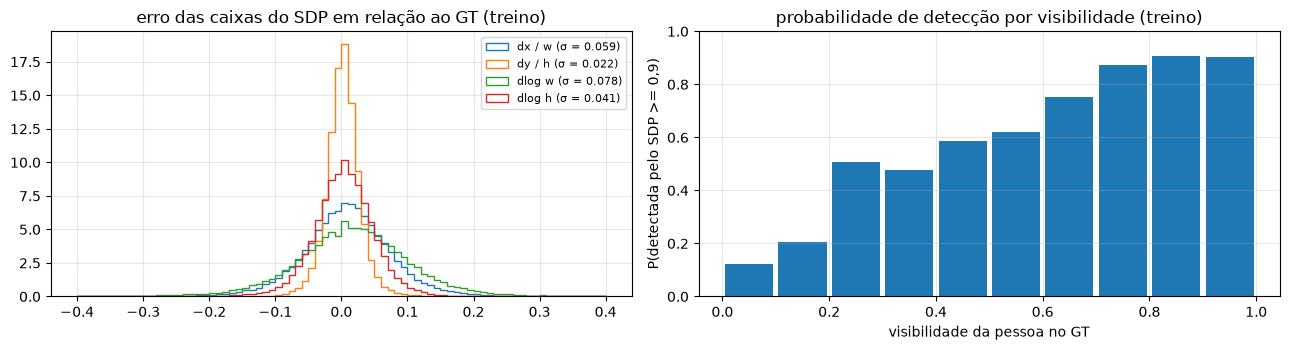

In [2]:
err, vis_all, hit_all, lag = [], [], [], []

for name in TRAIN:
    s = seqs[name]
    det_by_frame = split_by_frame(detections[name])
    errors_seq = {}
    for f, g in split_by_frame(s.gt).items():
        d = det_by_frame.get(f)
        hit = np.zeros(len(g), dtype=bool)
        if d is not None:
            for i, j in hungarian_match(box_iou_matrix(g[:, X1:Y2 + 1], d[:, X1:Y2 + 1]), 0.5):
                hit[i] = True
                G, D = g[i, X1:Y2 + 1], d[j, X1:Y2 + 1]
                gw, gh, dw, dh = G[2] - G[0], G[3] - G[1], D[2] - D[0], D[3] - D[1]
                e = [((D[0] + D[2]) - (G[0] + G[2])) / 2 / gw, ((D[1] + D[3]) - (G[1] + G[3])) / 2 / gh,
                     np.log(dw / gw), np.log(dh / gh)]
                err.append(e)
                errors_seq[(int(g[i, ID]), f)] = e
        vis_all.append(g[:, CONF])
        hit_all.append(hit)
    # pares de quadros seguidos da mesma pessoa, os dois detectados
    lag += [(e, errors_seq[(gid, f + 1)]) for (gid, f), e in errors_seq.items() if (gid, f + 1) in errors_seq]

err = np.asarray(err)
vis_all, hit_all = np.concatenate(vis_all), np.concatenate(hit_all)
lag_a, lag_b = np.asarray([p[0] for p in lag]), np.asarray([p[1] for p in lag])

LABELS = ["dx / w", "dy / h", "dlog w", "dlog h"]
sigma = 1.4826 * np.median(np.abs(err - np.median(err, axis=0)), axis=0)       # desvio robusto (MAD)
inlier = (np.abs(lag_a) < 0.5).all(axis=1) & (np.abs(lag_b) < 0.5).all(axis=1)
autocorr = [np.corrcoef(lag_a[inlier, k], lag_b[inlier, k])[0, 1] for k in range(4)]
jump = (lag_b[inlier] - lag_a[inlier]).std(axis=0)

VIS_BINS = np.array([0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.01])
P_DETECT = np.array([hit_all[(vis_all >= lo) & (vis_all < hi)].mean() for lo, hi in zip(VIS_BINS[:-1], VIS_BINS[1:])])

detector_error = pd.DataFrame({
    "desvio do erro (robusto)": sigma,
    "autocorrelação entre quadros seguidos": autocorr,
    "desvio do salto quadro a quadro (medido)": jump,
    "salto se o erro fosse independente (σ·√2)": err[(np.abs(err) < 0.5).all(axis=1)].std(axis=0) * np.sqrt(2),
}, index=LABELS)
print(detector_error.round(3).to_string())
print(f"\nfração dos quadros do GT (treino) com detecção casada: {hit_all.mean():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 3.6))
for k, label in enumerate(LABELS):
    axes[0].hist(err[:, k], bins=np.linspace(-0.4, 0.4, 81), histtype="step", density=True, label=f"{label} (σ = {sigma[k]:.3f})")
axes[0].set_title("erro das caixas do SDP em relação ao GT (treino)")
axes[0].legend(fontsize=8)
centers = (VIS_BINS[:-1] + np.minimum(VIS_BINS[1:], 1.0)) / 2
axes[1].bar(centers, P_DETECT, width=0.09, color="tab:blue")
axes[1].set_xlabel("visibilidade da pessoa no GT")
axes[1].set_ylabel("P(detectada pelo SDP >= 0,9)")
axes[1].set_ylim(0, 1)
axes[1].set_title("probabilidade de detecção por visibilidade (treino)")
for ax in axes:
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Duas coisas que um ruído gaussiano independente não captura: o erro é **correlacionado no tempo** (autocorrelação de ~0,4–0,5 entre quadros seguidos — a caixa erra parecido em quadros vizinhos, p. ex. enquanto um braço ou outra pessoa a corta), e as falhas são **correlacionadas com a oclusão** (o SDP acha 12 % das pessoas quase invisíveis e 90 % das visíveis). Um modelo treinado com ruído independente aprende a suavizar um tremor maior que o real e fica atrasado.

Então o treino não simula o detector: **reaproveita o próprio detector** (`src/dataset/trajectories.py::attach_detections` + `DetectorReplay`). Para cada pessoa do GT e cada quadro, a entrada é a caixa do SDP casada com ela naquele quadro (Hungarian, IoU ≥ 0,5), e o quadro conta como **não observado** onde o SDP não a achou. Por cima, com probabilidade 0,3, cada janela ganha um **bloco de ausência** de 1 a 40 quadros — as falhas reais são quase todas curtas, e o estado precisa aprender a rodar sem observação por mais tempo. (Se o SDP não achou a pessoa no primeiro quadro da janela, esse quadro recebe a caixa verdadeira com o ruído medido acima: toda track nasce de uma detecção.) A validação usa o mesmo esquema sobre as detecções reais das sequências de validação, com os blocos sorteados uma vez só.

In [3]:
REPLAY = DetectorReplay(occlusion_prob=0.3, occlusion_len=(1, 40), fallback=DetectionNoise(sigma=sigma))

trajectories = {
    n: attach_detections(extract_trajectories(s.gt, s.height, s.fps, sequence=n), s.gt, detections[n], s.height)
    for n, s in seqs.items()
}
train_traj = sum((trajectories[n] for n in TRAIN), [])
val_traj = sum((trajectories[n] for n in VAL), [])

WINDOW = 32
train_ds = TrajectoryDataset(train_traj, length=WINDOW, stride=16, noise=REPLAY, seed=SEED)
val_ds = TrajectoryDataset(val_traj, length=64, stride=32, noise=REPLAY, fixed=True, seed=SEED + 1)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, generator=torch.Generator().manual_seed(SEED))
val_loader = DataLoader(val_ds, batch_size=128, shuffle=False)

print(f"treino: {len(train_traj)} trajetórias -> {len(train_ds)} janelas de {WINDOW} quadros")
print(f"val   : {len(val_traj)} trajetórias -> {len(val_ds)} janelas de 64 quadros (blocos fixos, só monitoramento)")

batch = next(iter(val_loader))
print(f"fração de passos observados nas janelas de val: {batch['observed'][batch['valid'] > 0].mean():.2f}")

treino: 457 trajetórias -> 5688 janelas de 32 quadros
val   : 83 trajetórias -> 533 janelas de 64 quadros (blocos fixos, só monitoramento)
fração de passos observados nas janelas de val: 0.59


## 3. A perda e o treino

**Perda**: smooth-L1 sobre o **deslocamento** da caixa do quadro seguinte, na mesma parametrização da entrada — alvo $\Delta(b_{t+1} \mid b^{in}_t)$, previsão $W h_t$. É a perda L1/smooth-L1 sobre a caixa do enunciado, escrita relativa ao tamanho (a mesma escolha da regressão de caixas do Faster R-CNN): um erro de 5 px pesa mais numa pessoa de 60 px que numa de 400. O alvo é sempre a caixa verdadeira, inclusive nos passos sem observação — é dali que vem o gradiente que ensina o estado a atravessar a oclusão.

**Regime**: *scheduled sampling* — a probabilidade de alimentar a própria previsão no lugar da observação cresce linearmente de 0 a 0,5 ao longo das épocas (nos passos sem observação a entrada é sempre a própria previsão, em qualquer regime: é o que acontece na inferência). Sem isso o modelo só veria a própria previsão nos buracos simulados, e a distribuição da entrada mudaria debaixo dele na inferência (o Eixo 2 da Parte 3 mede isso). BPTT na janela inteira de 32 quadros, *gradient clipping* em norma 1, Adam com decaimento cosseno.

**Seleção**: número fixo de épocas, sem *early stopping* — as sequências de validação aparecem na curva só como monitoramento e não decidem nada. Se o checkpoint já existe em `results/`, a célula só carrega.

carregado de results\2_motion_gru.pt

GRU: 14084 parâmetros


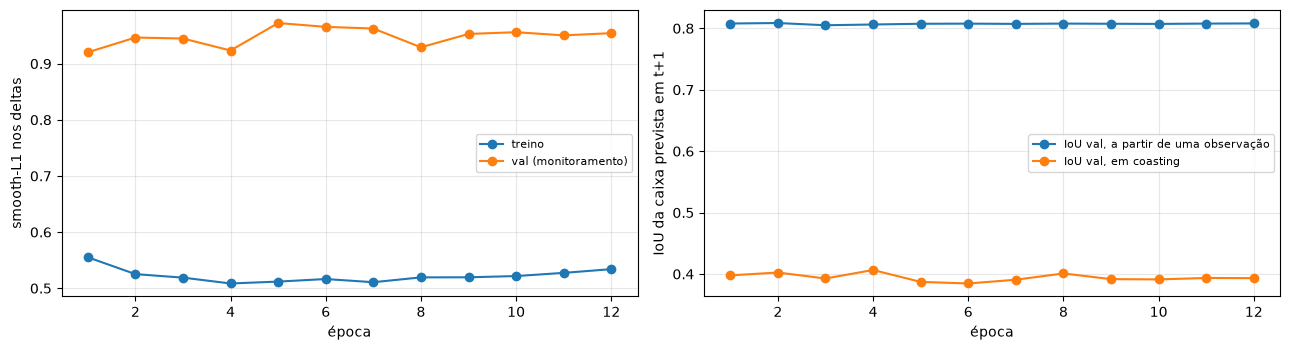

In [4]:
CKPT = os.path.join(RESULTS_DIR, "2_motion_gru.pt")

TRAIN_CFG = dict(cell="gru", hidden_size=64, epochs=12, lr=3e-3, batch_size=64, window=WINDOW,
                 sampling_max=0.5, clip_grad=1.0, loss="smooth_l1", beta=0.1, seed=SEED)


def train_motion(model_kwargs, loss_name, path, cfg=TRAIN_CFG, **loss_kwargs):
    if os.path.exists(path):
        model, ckpt = load_motion_model(path, device)
        print(f"carregado de {path}")
        return model, pd.DataFrame(ckpt["history"])

    torch.manual_seed(cfg["seed"])
    model = MotionModel(**model_kwargs).to(device)
    loss_fn = make_box_loss(loss_name, **loss_kwargs)
    optimizer = create_optimizer("Adam", model, lr=cfg["lr"])
    scheduler = create_scheduler("cosine", optimizer, T_max=cfg["epochs"])

    history = []
    for epoch in range(cfg["epochs"]):
        sampling = cfg["sampling_max"] * epoch / max(cfg["epochs"] - 1, 1)
        t0 = time.time()
        train_loss, grad_norm = train_motion_epoch(model, train_loader, optimizer, loss_fn, device,
                                                   sampling_prob=sampling, clip_grad=cfg["clip_grad"])
        scheduler.step()
        ev = evaluate_motion(model, val_loader, loss_fn, device)
        history.append({"epoch": epoch + 1, "sampling_prob": sampling, "train_loss": train_loss,
                        "val_loss": ev["loss"], "grad_norm": grad_norm,
                        "val_iou_observed": float(ev["iou"][ev["k"] == 0].mean()),
                        "val_iou_coasting": float(ev["iou"][ev["k"] >= 1].mean()),
                        "seconds": time.time() - t0})
        print(f"época {epoch + 1:2d} | sampling {sampling:.2f} | treino {train_loss:.4f} | val {ev['loss']:.4f} | "
              f"IoU val (observado / coasting) {history[-1]['val_iou_observed']:.3f} / {history[-1]['val_iou_coasting']:.3f} "
              f"| {history[-1]['seconds']:.0f} s")

    save_motion_model(model, path, history=history, train_cfg=cfg, inputs="DetectorReplay (SDP >= 0.9)",
                      occlusion_prob=0.3, occlusion_len=(1, 40))
    return model.eval(), pd.DataFrame(history)


motion_model, history = train_motion(dict(cell="gru", hidden_size=64), "smooth_l1", CKPT, beta=0.1)
print(f"\nGRU: {count_parameters(motion_model)} parâmetros")

fig, axes = plt.subplots(1, 2, figsize=(13, 3.6))
axes[0].plot(history["epoch"], history["train_loss"], marker="o", label="treino")
axes[0].plot(history["epoch"], history["val_loss"], marker="o", label="val (monitoramento)")
axes[0].set_ylabel("smooth-L1 nos deltas")
axes[1].plot(history["epoch"], history["val_iou_observed"], marker="o", label="IoU val, a partir de uma observação")
axes[1].plot(history["epoch"], history["val_iou_coasting"], marker="o", label="IoU val, em coasting")
axes[1].set_ylabel("IoU da caixa prevista em t+1")
for ax in axes:
    ax.set_xlabel("época")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

**Leitura.** A GRU tem 14 mil parâmetros e converge em poucas épocas: o IoU de validação a partir de uma observação estabiliza em 0,81 já na primeira, e o de coasting oscila em torno de 0,39–0,40. A perda de treino cai até a 4ª época e volta a subir no fim — não é sobreajuste: é o *scheduled sampling* aumentando (de 0 a 0,5), o modelo passa a receber a própria previsão no lugar de metade das observações, e a tarefa fica mais difícil de propósito. A perda de validação é ruidosa (são só 2 sequências e 83 trajetórias); ela não decide nada, só mostra que não há divergência.

### A referência honesta: Kalman de velocidade constante

O enunciado permite um filtro de Kalman de velocidade constante **apenas** como baseline de comparação — "honesto e frequentemente difícil de bater". O nosso (`src/nn/tracking.py::KalmanMotion`, escrito do zero) tem estado $(c_x, c_y, w, h)$ e as quatro velocidades, em pixels; os desvios do ruído de processo e de medida são escolhidos no **treino**, pelo IDF1 médio com a regra do baseline — o mesmo tratamento que a GRU recebe. Assim, a comparação da GRU é contra o melhor Kalman que conseguimos, não contra um Kalman mal calibrado.

In [5]:
def run(motion_factory, cfg, names):
    out = {}
    for name in names:
        s = seqs[name]
        out[name] = track_sequence(detections[name], s.n_frames, motion=motion_factory(s), **cfg)
    return out


def evaluate(tracks, label):
    rows = []
    for name, pred in tracks.items():
        r = evaluate_sequence(pred, seqs[name], detection_map=False)
        rows.append({"sequence": name, "split": split_of(name), "source": label, **r})
    return pd.DataFrame(rows)


# --- Kalman: ruídos (em pixels) ajustados no treino, com a regra do baseline
t0 = time.time()
rows = []
for q in [4.0, 16.0, 64.0]:
    for r_noise in [0.5, 2.0, 8.0]:
        res = evaluate(run(lambda s: KalmanMotion(q, r_noise), BASELINE_CFG, TRAIN), "kalman")
        rows.append({"process_noise": q, "measurement_noise": r_noise, "IDF1": res["IDF1"].mean()})
kalman_noise = pd.DataFrame(rows).set_index(["process_noise", "measurement_noise"])
KALMAN_Q, KALMAN_R = (float(v) for v in kalman_noise["IDF1"].idxmax())
print(kalman_noise["IDF1"].unstack().round(3).to_string())
print(f"Kalman: process_noise = {KALMAN_Q}, measurement_noise = {KALMAN_R}  ({time.time() - t0:.0f} s)")

measurement_noise    0.5    2.0    8.0
process_noise                         
4.0                0.612  0.604  0.609
16.0               0.614  0.614  0.607
64.0               0.610  0.610  0.611
Kalman: process_noise = 16.0, measurement_noise = 0.5  (104 s)


O Kalman é pouco sensível aos ruídos na faixa testada (IDF1 médio de 0,604 a 0,614). O escolhido, ruído de processo de 16 px e de medida de 0,5 px, confia quase totalmente na medida e deixa a velocidade se adaptar rápido — com as caixas do SDP, filtrar muito a posição atrasa mais do que o tremor atrapalha.

## 4. A previsão sozinha, antes do rastreador

Antes de pôr o modelo no rastreador, a pergunta isolada: **dada a história de observações (com erro e buracos), quão bem cada modelo prevê a caixa do quadro seguinte?** Nas janelas de validação (detecções reais do SDP, blocos de ausência fixos), por número de passos $k$ desde a última observação — $k = 0$ é a previsão a partir de uma detecção, $k \geq 1$ é o $k$-ésimo quadro de coasting. Referências sem aprendizado, nas mesmas janelas: a **última caixa observada** (o que a Parte 1 usa), **velocidade constante** ingênua (a velocidade entre as duas últimas observações, extrapolada) e o **Kalman** ajustado acima.

IoU médio entre a caixa prevista e a verdadeira, por passos desde a última observação (validação):

                                    k=0    k=1  k=2-3  k=4-7  k=8-15  k=16-31  k=32-63  % IoU>=0,3 em coasting
modelo                                                                                                        
última caixa observada (Parte 1)  0.786  0.660  0.571  0.440   0.281    0.152    0.068                  51.356
velocidade constante              0.742  0.609  0.525  0.397   0.232    0.119    0.058                  46.278
Kalman vel. constante             0.791  0.672  0.595  0.493   0.345    0.197    0.080                  56.798
GRU (Trilha A)                    0.808  0.687  0.613  0.509   0.364    0.200    0.071                  56.865


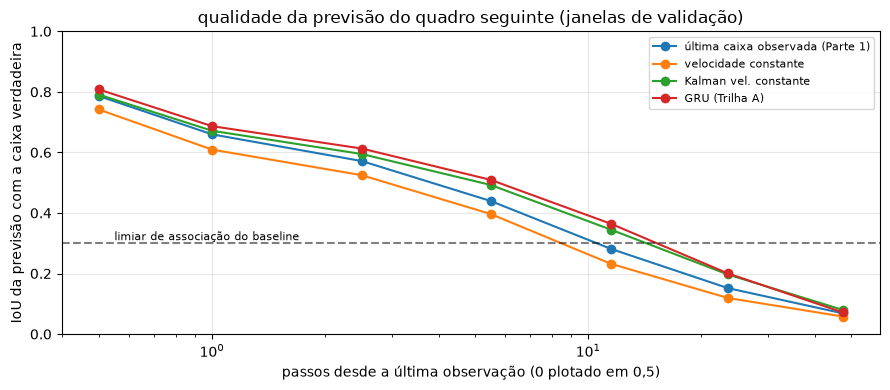

In [6]:
def windowed_iou(predict_fn):
    ks, ious, cams = [], [], []
    for b in val_loader:
        pred = predict_fn(b)
        iou = box_iou_cxcywh(pred[:, :-1], b["boxes"][:, 1:])
        k = steps_since_observation(b["observed"])[:, :-1]
        m = b["valid"][:, 1:] > 0.5
        ks.append(k[m].numpy())
        ious.append(iou[m].numpy())
    return np.concatenate(ks), np.concatenate(ious)


def kalman_window_predictions(b, scale=1080.0):
    # as janelas de val (MOT17-09 e 10) são 1080p: caixas / altura * 1080 = pixels
    from src.nn.boxes import cxcywh_to_xyxy, xyxy_to_cxcywh
    kf = KalmanMotion(KALMAN_Q, KALMAN_R)
    inputs = b["inputs"].numpy().astype(np.float64) * scale
    obs = b["observed"][..., 0].numpy() > 0.5
    out = np.zeros_like(inputs)
    for i in range(inputs.shape[0]):
        st = kf.init(cxcywh_to_xyxy(inputs[i, 0]), 1.0, 0)
        out[i, 0] = xyxy_to_cxcywh(kf.predict(st))
        for t in range(1, inputs.shape[1]):
            st = kf.update(st, cxcywh_to_xyxy(inputs[i, t]), 1.0, t) if obs[i, t] else kf.coast(st, t)
            out[i, t] = xyxy_to_cxcywh(kf.predict(st))
    return torch.from_numpy(out / scale).float()


assert all(seqs[n].height == 1080 for n in VAL)

with torch.no_grad():
    curves = {
        "última caixa observada (Parte 1)": windowed_iou(lambda b: naive_motion_predictions(b["inputs"], b["observed"], kind="static")),
        "velocidade constante": windowed_iou(lambda b: naive_motion_predictions(b["inputs"], b["observed"], kind="velocity")),
        "Kalman vel. constante": windowed_iou(kalman_window_predictions),
        "GRU (Trilha A)": windowed_iou(lambda b: motion_model(b["inputs"].to(device), b["observed"].to(device), b["dt"].to(device))["box"].cpu()),
    }

K_BINS = [(0, 0), (1, 1), (2, 3), (4, 7), (8, 15), (16, 31), (32, 63)]
rows = []
for label, (k, iou) in curves.items():
    row = {"modelo": label}
    for lo, hi in K_BINS:
        sel = (k >= lo) & (k <= hi)
        row[f"k={lo}" if lo == hi else f"k={lo}-{hi}"] = iou[sel].mean() if sel.any() else np.nan
    row["% IoU>=0,3 em coasting"] = 100 * np.mean(iou[k >= 1] >= 0.3)
    rows.append(row)

prediction_table = pd.DataFrame(rows).set_index("modelo")
print("IoU médio entre a caixa prevista e a verdadeira, por passos desde a última observação (validação):\n")
print(prediction_table.round(3).to_string())

fig, ax = plt.subplots(figsize=(9, 4))
for label, (k, iou) in curves.items():
    xs = [np.mean([lo, hi]) for lo, hi in K_BINS]
    ys = [iou[(k >= lo) & (k <= hi)].mean() for lo, hi in K_BINS]
    ax.plot([max(x, 0.5) for x in xs], ys, marker="o", label=label)
ax.axhline(BASELINE_CFG["iou_threshold"], color="k", linestyle="--", alpha=0.5)
ax.text(0.55, BASELINE_CFG["iou_threshold"] + 0.01, "limiar de associação do baseline", fontsize=8)
ax.set_xscale("log")
ax.set_xlabel("passos desde a última observação (0 plotado em 0,5)")
ax.set_ylabel("IoU da previsão com a caixa verdadeira")
ax.set_ylim(0, 1)
ax.grid(alpha=0.3)
ax.legend(fontsize=8)
ax.set_title("qualidade da previsão do quadro seguinte (janelas de validação)")
plt.tight_layout()
plt.show()

**A GRU é o melhor previsor até ~15 quadros sem observação**: IoU 0,808 a partir de uma detecção (Kalman 0,791, última caixa 0,786), 0,687 após 1 quadro de coasting (0,672 e 0,660), 0,509 após 4–7 (0,493 e 0,440) e 0,364 após 8–15 (0,345 e 0,281). Dois detalhes:

- a **velocidade constante ingênua é pior que ficar parado** (0,742 a partir de uma detecção): a velocidade estimada com duas caixas ruidosas é o ruído amplificado. O Kalman resolve isso filtrando; a GRU aprendeu a filtrar o erro do próprio detector, com a correlação temporal real;
- **depois de ~16 quadros todos convergem** (~0,2 em 16–31, < 0,1 em 32–63): sem observação por mais de meio segundo, ninguém sabe onde a pessoa está. Um modelo de movimento sozinho não atravessa uma oclusão longa — só a encurta.

## 5. No rastreador: baseline × Kalman × GRU, nas mesmas sequências

O mesmo `Tracker` da Parte 1 (`src/nn/tracking.py`), a mesma fonte de detecções; só muda o modelo de movimento que fornece a caixa prevista de cada track:

- **última caixa observada** — o baseline da Parte 1, com a regra que ele escolheu no treino;
- **Kalman de velocidade constante** (`KalmanMotion`) — permitido só como referência, com os ruídos ajustados na seção 3;
- **GRU** (`RNNMotion`) — um passo da célula por quadro para todas as tracks vivas, em lote.

Uma caixa prevista melhor muda o ponto ótimo da regra (dá para exigir mais IoU, ou esperar mais antes de matar a track), então cada modelo de movimento ganha a sua própria pequena grade de limiar de IoU × `max_age` — **no treino**, como o baseline ganhou a dele. O matching fica Hungarian (o da regra do baseline).

In [7]:
MOTIONS = {
    "última caixa (Parte 1)": lambda s: StaticMotion(),
    "Kalman vel. constante": lambda s: KalmanMotion(KALMAN_Q, KALMAN_R),
    "GRU (Trilha A)": lambda s: RNNMotion(motion_model, s.height, s.fps, device=device),
}

ASSOC_IOU = [0.2, 0.3, 0.4, 0.5]
ASSOC_AGE = [10, 20, 40, 60]

t0 = time.time()
rows = []
for label in ["Kalman vel. constante", "GRU (Trilha A)"]:
    for iou_th in ASSOC_IOU:
        for age in ASSOC_AGE:
            cfg = dict(matching="hungarian", iou_threshold=iou_th, max_age=age)
            res = evaluate(run(MOTIONS[label], cfg, TRAIN), label)
            rows.append({"motion": label, "iou_threshold": iou_th, "max_age": age, "IDF1": res["IDF1"].mean(),
                         "IDSW_per_gt_id": res["IDSW_per_gt_id"].mean(), "id_ratio": res["id_ratio"].mean()})
assoc_grid = pd.DataFrame(rows)
assoc_grid.to_csv(os.path.join(RESULTS_DIR, "2_association_grid.csv"), index=False)
print(f"grade em {time.time() - t0:.0f} s\n")

CFGS = {"última caixa (Parte 1)": dict(BASELINE_CFG)}
for label, part in assoc_grid.groupby("motion"):
    best = part.loc[part["IDF1"].idxmax()]
    CFGS[label] = dict(matching="hungarian", iou_threshold=float(best["iou_threshold"]), max_age=int(best["max_age"]))
    print(f"{label}: IDF1 médio no treino por (limiar de IoU x max_age)")
    print(part.pivot(index="iou_threshold", columns="max_age", values="IDF1").round(3).to_string(), "\n")

for label, cfg in CFGS.items():
    print(f"{label:28s} -> {cfg}")

grade em 574 s

GRU (Trilha A): IDF1 médio no treino por (limiar de IoU x max_age)
max_age           10     20     40     60
iou_threshold                            
0.2            0.585  0.601  0.597  0.593
0.3            0.589  0.606  0.609  0.603
0.4            0.574  0.591  0.593  0.586
0.5            0.545  0.560  0.561  0.555 

Kalman vel. constante: IDF1 médio no treino por (limiar de IoU x max_age)
max_age           10     20     40     60
iou_threshold                            
0.2            0.581  0.602  0.591  0.593
0.3            0.589  0.614  0.620  0.617
0.4            0.584  0.605  0.608  0.608
0.5            0.545  0.561  0.563  0.562 

última caixa (Parte 1)       -> {'matching': 'hungarian', 'iou_threshold': 0.3, 'max_age': 20}
GRU (Trilha A)               -> {'matching': 'hungarian', 'iou_threshold': 0.3, 'max_age': 40}
Kalman vel. constante        -> {'matching': 'hungarian', 'iou_threshold': 0.3, 'max_age': 40}


Os dois modelos de movimento preferem **`max_age` = 40**, o dobro do baseline. É exatamente a regra que a Parte 1 mostrou ser impossível com a caixa parada (lá, `max_age` 60 piorava: a track morta-viva capturava quem passasse pelo lugar). Com a caixa andando junto com a pessoa, esperar mais deixa de ser perigoso. O limiar de IoU continua 0,3 nos três.

In [8]:
METRIC_COLS = ["IDF1", "IDP", "IDR", "IDSW", "FRAG", "IDSW_per_gt_id", "n_gt_ids", "n_pred_ids",
               "count_error", "id_ratio", "MOTA", "mAP"]

tracks = {}
frames_ = []
for label, factory in MOTIONS.items():
    t0 = time.time()
    tracks[label] = run(factory, CFGS[label], SEQUENCES)
    elapsed = time.time() - t0
    rows = []
    for name, pred in tracks[label].items():
        r = evaluate_sequence(pred, seqs[name], detection_map=True)
        rows.append({"sequence": name, "split": split_of(name), "source": label, **r})
    df = pd.DataFrame(rows)
    df["track_seconds"] = elapsed
    frames_.append(df)

results = pd.concat(frames_, ignore_index=True)


def combined(df):
    idtp, idfp, idfn = df["IDTP"].sum(), df["IDFP"].sum(), df["IDFN"].sum()
    return pd.Series({
        "IDF1": 2 * idtp / (2 * idtp + idfp + idfn), "IDSW": df["IDSW"].sum(), "FRAG": df["FRAG"].sum(),
        "IDSW_per_gt_id": df["IDSW"].sum() / df["n_gt_ids"].sum(),
        "id_ratio": df["n_pred_ids"].sum() / df["n_gt_ids"].sum(),
        "MOTA": 1 - (df["FN"].sum() + df["FP"].sum() + df["IDSW"].sum()) / (df["TP"].sum() + df["FN"].sum()),
    })


side_by_side = results.pivot(index="sequence", columns="source", values=["IDF1", "IDSW_per_gt_id", "id_ratio"])
side_by_side = side_by_side.reindex(columns=list(MOTIONS), level=1)
print("por sequência (val = MOT17-09 e MOT17-10):\n")
print(side_by_side.round(3).to_string())

summary = pd.concat({
    split_name: results[results.split.isin(splits)].groupby("source").apply(combined).loc[list(MOTIONS)]
    for split_name, splits in [("treino", ["treino"]), ("val", ["val"]), ("todas", ["treino", "val"])]
}, names=["split"])
print("\ncombinado (IDTP/IDFP/IDFN e contadores somados sobre as sequências):\n")
print(summary.round(3).to_string())
print("\ntempo de rastreamento das 7 sequências (s):",
      results.groupby("source")["track_seconds"].first().loc[list(MOTIONS)].round(1).to_dict())

por sequência (val = MOT17-09 e MOT17-10):

                           IDF1                                              IDSW_per_gt_id                                                    id_ratio                                     
source   última caixa (Parte 1) Kalman vel. constante GRU (Trilha A) última caixa (Parte 1) Kalman vel. constante GRU (Trilha A) última caixa (Parte 1) Kalman vel. constante GRU (Trilha A)
sequence                                                                                                                                                                                    
MOT17-02                  0.426                 0.469          0.436                  4.032                 3.919          4.629                  3.210                 2.952          2.613
MOT17-04                  0.691                 0.737          0.748                  2.108                 1.747          1.952                  1.325                 1.157          1.084
MOT17-05   

**O resultado, sem enfeite.** A memória recorrente conserta uma parte grande do fracasso da Parte 1 — IDF1 combinado de 0,594 para 0,632, ID switches de 1.438 para 1.180 (−18 %) e identidades inventadas de 2,01 para 1,62 por identidade verdadeira —, mas **não supera o Kalman de velocidade constante** bem ajustado (0,641; 1.048 switches): empata no treino (0,655 vs. 0,657) e perde na validação (0,519 vs. 0,557).

- Os maiores ganhos sobre o baseline são onde a Parte 1 dizia: **MOT17-13** (câmera no ônibus, o maior movimento aparente) vai de 0,505 a 0,593 com a GRU e os switches por identidade caem de 3,7 para 2,0; **MOT17-04** (o mais denso) vai de 0,691 a 0,748. A GRU é a melhor das três nessas duas.
- O Kalman é melhor nas outras cinco, e a maior diferença é o **MOT17-09** (validação): 0,605 contra 0,514 — com *menos* switches e *menos* identidades inventadas na GRU (1,65 vs. 1,77 switches por id; 1,27 vs. 1,39 ids por id). Com só 26 pessoas, o IDF1 dessa sequência é dominado por poucas trajetórias longas: basta uma troca no começo de uma delas para o IDF1 cair muito, mesmo com menos trocas no total. A validação tem 83 identidades; a diferença de 0,04 no IDF1 combinado vem quase toda dessa sequência.
- Custo: 28 s para rastrear as 7 sequências com a GRU (um passo da célula por quadro, em lote) contra 22 s do Kalman e 4 s da caixa parada.

Por que prever melhor (seção 4) não vira IDF1 melhor? Porque a associação usa a caixa prevista só através de um limiar de IoU de 0,3: a partir de uma detecção, os três modelos já passam desse limiar com folga (IoU 0,79–0,81), então prever 2 pontos melhor quase nunca muda um casamento. Os casamentos que mudam são os de coasting — e lá os dois modelos de movimento empatam (56,8 % vs. 56,9 % das previsões em coasting acima de 0,3). O que sobra de erro não é de movimento: é ambiguidade entre vizinhos e oclusões longas demais para qualquer extrapolação.

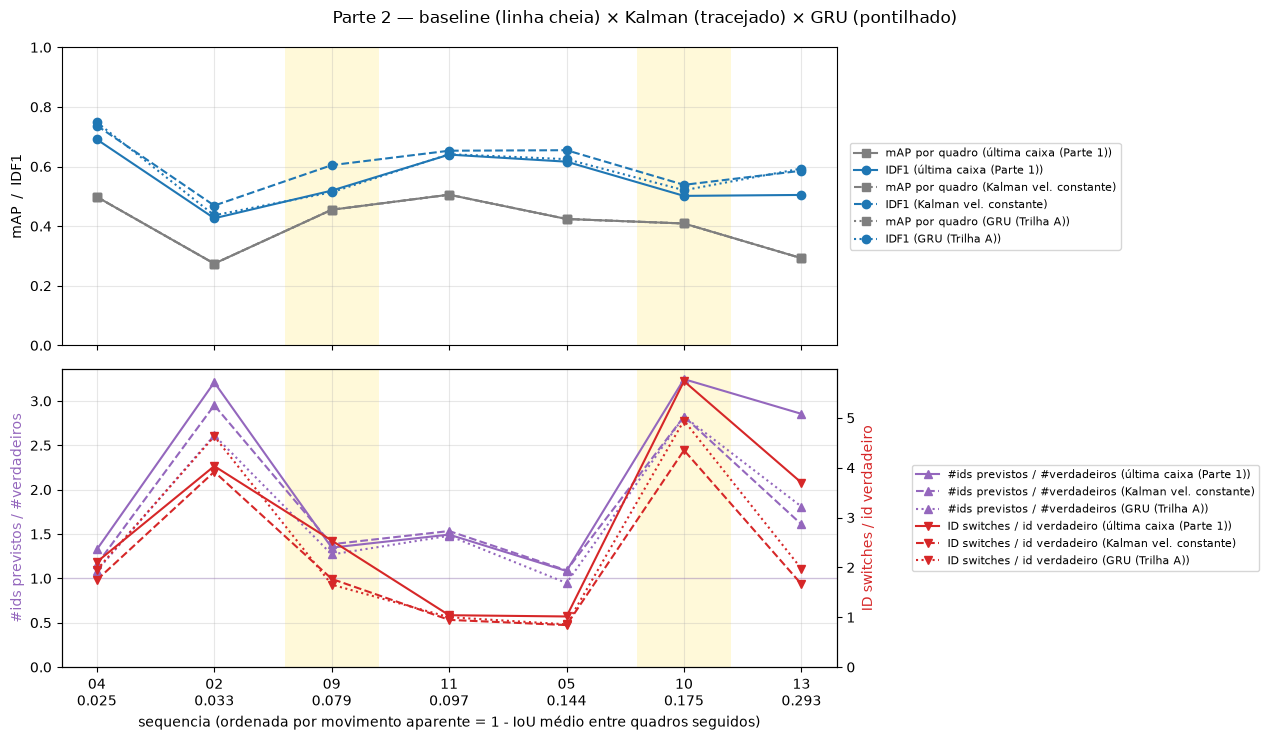

In [9]:
order = part1["sequence_order"]
stats = pd.read_csv(os.path.join(RESULTS_DIR, "1_sequence_statistics.csv"), index_col=0)
axis_values = [f"{stats.loc[n, 'apparent_motion']:.3f}" for n in order]

fig = plot_decoupling(results, order, sources=list(MOTIONS),
                      axis_label="movimento aparente = 1 - IoU médio entre quadros seguidos",
                      axis_values=axis_values, highlight=VAL,
                      title="Parte 2 — baseline (linha cheia) × Kalman (tracejado) × GRU (pontilhado)")
fig.savefig(os.path.join(RESULTS_DIR, "2_side_by_side.png"), dpi=130, bbox_inches="tight")
plt.show()

## 6. Em que aspecto a memória melhora o fracasso da Parte 1

As mesmas duas medidas do diagnóstico da Parte 1, agora para os três modelos de movimento: a fração das recapturas que mantêm o id em função da duração do buraco, separada por tipo de câmera, e a decomposição das perdas de identidade por causa.

perdas de identidade por causa (todas as sequências):

causa                   morta e renascida (g > max_age)  perdida no coasting (1 <= g <= max_age)  troca entre vizinhos (g = 0)  total
source                                                                                                                               
última caixa (Parte 1)                              206                                      485                           747   1438
Kalman vel. constante                               101                                      525                           422   1048
GRU (Trilha A)                                       94                                      478                           608   1180
total                                               401                                     1488                          1777   3666

por tipo de câmera:

causa                          morta e renascida (g > max_age)  perdida no coasting (1 <= g <= max_age)  troca entre vi

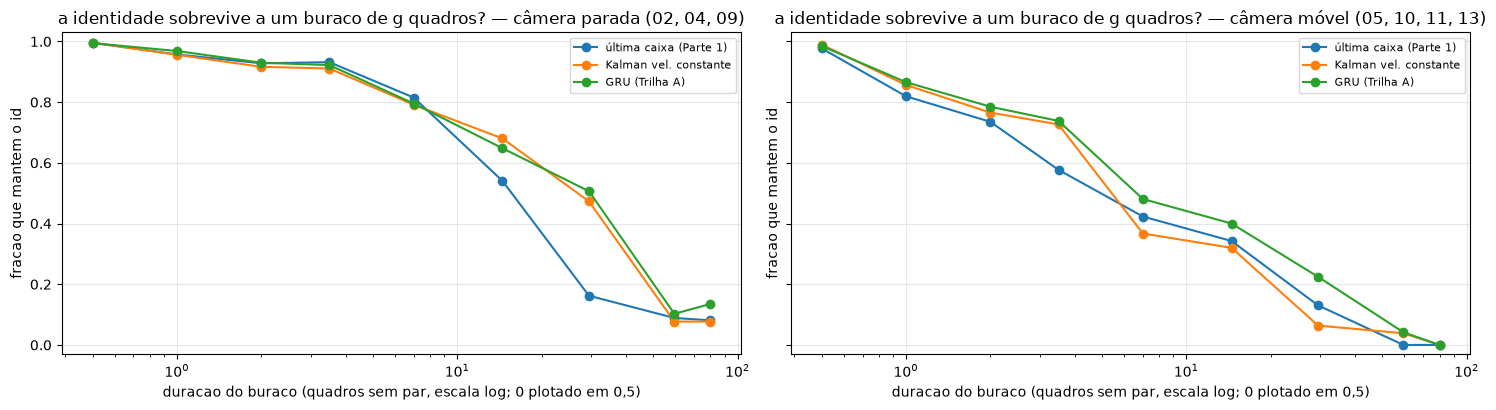

In [10]:
def loss_events(label):
    K = CFGS[label]["max_age"]
    rows = []
    for name in SEQUENCES:
        pred = remove_distractor_matches(tracks[label][name], seqs[name].gt_all)
        for e in reacquisition_events(pred, seqs[name].gt):
            e.update(sequence=name, camera=seqs[name].meta["camera"], source=label)
            if e["kept"]:
                e["causa"] = "mantido"
            elif e["gap"] == 0:
                e["causa"] = "troca entre vizinhos (g = 0)"
            elif e["gap"] <= K:
                e["causa"] = "perdida no coasting (1 <= g <= max_age)"
            else:
                e["causa"] = "morta e renascida (g > max_age)"
            rows.append(e)
    return pd.DataFrame(rows)


events = pd.concat([loss_events(label) for label in MOTIONS], ignore_index=True)
losses = events[~events["kept"]]

print("perdas de identidade por causa (todas as sequências):\n")
print(pd.crosstab(losses["source"], losses["causa"], margins=True, margins_name="total").loc[list(MOTIONS) + ["total"]].to_string())
print("\npor tipo de câmera:\n")
print(pd.crosstab([losses["camera"], losses["source"]], losses["causa"]).to_string())

fig, axes = plt.subplots(1, 2, figsize=(15, 4.2), sharey=True)
for ax, camera, title in [(axes[0], "parada", "câmera parada (02, 04, 09)"), (axes[1], "movel", "câmera móvel (05, 10, 11, 13)")]:
    curves_cam = {label: keep_rate_by_gap(events[(events.source == label) & (events.camera == camera)].to_dict("records"))
                  for label in MOTIONS}
    plot_keep_rate(curves_cam, ax=ax, title=f"a identidade sobrevive a um buraco de g quadros? — {title}")
plt.tight_layout()
plt.show()

**Onde a memória ajuda — exatamente onde a Parte 1 apontou.**

- **Câmera móvel**: a identidade sobrevive a um buraco de 1 quadro em 87 % dos casos com a GRU (82 % no baseline), a 3–4 quadros em 74 % (58 %), a 5–9 em 48 % (42 %; Kalman 37 %) e a 20–39 em 22 % (13 %; Kalman 6 %). A GRU é a melhor curva das três em quase todo o eixo: a previsão anda com a pessoa *e* com a câmera.
- **Câmera parada**: até 9 quadros as três curvas coincidem (com a câmera parada, ficar parado já é uma boa previsão para buracos curtos); para buracos de 10–19 e 20–39 quadros, GRU e Kalman mantêm 65–68 % e 47–51 % contra 54 % e 16 % do baseline — é o `max_age` maior funcionando sem capturar a pessoa errada.
- **Nas causas**: "morta e renascida" cai à **metade** (206 → 94 com a GRU, 101 com o Kalman) — as oclusões longas da Parte 1. "Perdida no coasting" quase não muda (485 → 478) — mas agora ela inclui buracos de até 40 quadros, que antes eram mortes. E as **trocas entre vizinhos** caem de 747 para 608 com a GRU e para 422 com o Kalman: é aí, e não no movimento, que o Kalman ganha da GRU — nas câmeras paradas a GRU troca vizinhos mais vezes que o próprio baseline (246 vs. 198). Diagnosticar por quê é trabalho da galeria de falhas (Parte 4).

### Quais perdas do baseline a memória resolve

As curvas mostram a média; aqui, perda por perda. Para cada perda de identidade do baseline com buraco ($g \geq 1$), olhamos a mesma pessoa nos mesmos quadros na saída do Kalman e da GRU: o id que ela tinha no último quadro casado antes do buraco é o mesmo que ela tem quando volta? Separado pela causa da Parte 1 (buraco até `max_age` = 20 vs. maior).

In [11]:
from src.nn.metrics import frame_matching

matchings = {
    label: {name: frame_matching(remove_distractor_matches(tracks[label][name], seqs[name].gt_all), seqs[name].gt)[0]
            for name in SEQUENCES}
    for label in MOTIONS
}

base = events[(events.source == "última caixa (Parte 1)") & (~events.kept) & (events.gap >= 1)].copy()
base["t_last"] = base["frame"] - base["gap"] - 1
base["buraco"] = np.where(base["gap"] <= BASELINE_CFG["max_age"], "1 <= g <= 20", "g > 20")

for label in ["Kalman vel. constante", "GRU (Trilha A)"]:
    m = matchings[label]
    before = [m[r.sequence].get(r.t_last, {}).get(r.gt_id) for r in base.itertuples()]
    after = [m[r.sequence].get(r.frame, {}).get(r.gt_id) for r in base.itertuples()]
    base[label] = [b is not None and b == a for b, a in zip(before, after)]

resolved = base.groupby(["camera", "buraco"])[["Kalman vel. constante", "GRU (Trilha A)"]].mean()
resolved["perdas do baseline"] = base.groupby(["camera", "buraco"]).size()
print("fração das perdas do baseline (com buraco) em que o outro modelo mantém o id através do mesmo buraco:\n")
print(resolved.round(2).to_string())
print(f"\ntotal: Kalman resolve {base['Kalman vel. constante'].mean():.0%}, GRU resolve {base['GRU (Trilha A)'].mean():.0%} "
      f"das {len(base)} perdas com buraco do baseline")

fração das perdas do baseline (com buraco) em que o outro modelo mantém o id através do mesmo buraco:

                     Kalman vel. constante  GRU (Trilha A)  perdas do baseline
camera buraco                                                                 
movel  1 <= g <= 20                   0.35            0.32                 327
       g > 20                         0.01            0.11                  71
parada 1 <= g <= 20                   0.32            0.32                 158
       g > 20                         0.21            0.25                 135

total: Kalman resolve 28%, GRU resolve 29% das 691 perdas com buraco do baseline


Das 691 perdas do baseline que passam por um buraco, o Kalman resolve 28 % e a GRU 29 % — empate no agregado, mas com perfis diferentes. Para buracos de até 20 quadros os dois resolvem ~1/3 (as outras 2/3 não são de movimento: a pessoa volta perto de outra track, ou a detecção que volta é de outra pessoa). Para buracos **mais longos que 20 quadros com câmera móvel**, a GRU resolve 11 % e o Kalman 1 %: depois de 1 s sem observação, extrapolar a última velocidade com a câmera andando joga a caixa longe; a GRU, treinada com blocos de até 40 quadros sem observação, aprendeu a desacelerar a extrapolação (seção 4: ela é a melhor até 15 quadros e não piora depois). Com câmera parada, as duas resolvem cerca de 1/4 das perdas longas (25 % e 21 %).

Um desses casos nas imagens, escolhido por regra: entre as perdas do baseline em sequências de **câmera móvel** que a GRU resolve, com a pessoa bem visível (≥ 0,6) antes e depois do buraco, a de buraco mais longo (validação primeiro, se houver). Em cada linha, a caixa **prevista** pelo modelo de movimento para a track que estava com a pessoa (tracejado amarelo — o "mapa intermediário" da recorrência), a saída do rastreador (cor = id) e o GT da pessoa (branco).

MOT17-10 (câmera móvel), GT 56: buraco de 10 quadros entre t = 435 e t = 446; visibilidade 1.00 -> 1.00


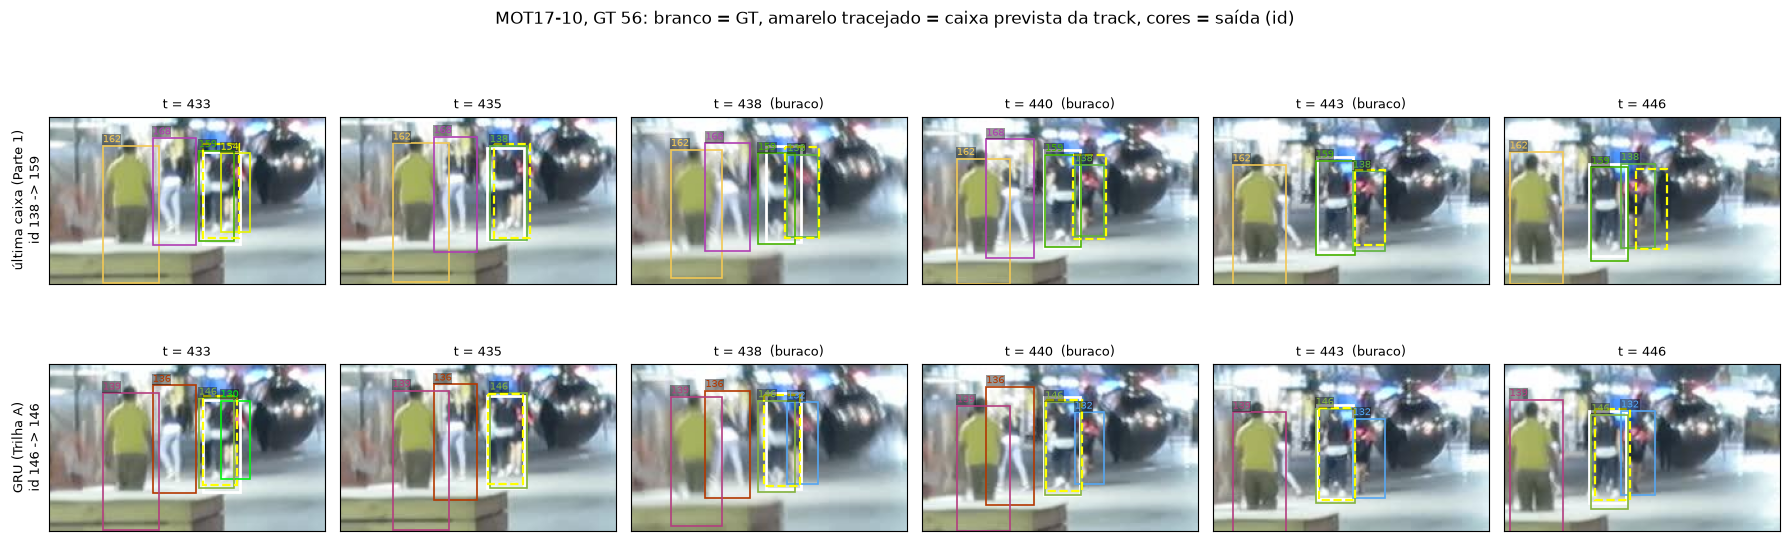

In [12]:
vis_lookup = {name: {(int(f), int(i)): v for f, i, v in seqs[name].gt[:, [FRAME, ID, CONF]]} for name in SEQUENCES}
cand = base[(base.camera == "movel") & base["GRU (Trilha A)"]].copy()
cand["vis_last"] = [vis_lookup[r.sequence].get((r.t_last, r.gt_id), 0) for r in cand.itertuples()]
cand["vis_back"] = [vis_lookup[r.sequence].get((r.frame, r.gt_id), 0) for r in cand.itertuples()]
cand = cand[(cand.vis_last >= 0.6) & (cand.vis_back >= 0.6)]
cand["is_val"] = cand.sequence.isin(VAL)
e = cand.sort_values(["is_val", "gap"], ascending=[False, False]).iloc[0]

name, gid, t_last, t_back = e.sequence, int(e.gt_id), int(e.t_last), int(e.frame)
s = seqs[name]
subject = s.gt[s.gt[:, ID] == gid]
frames = sorted(set(np.linspace(t_last, t_back, 5).round().astype(int).tolist() + [max(t_last - 2, 0)]))

box = subject[(subject[:, FRAME] >= frames[0]) & (subject[:, FRAME] <= frames[-1]), X1:Y2 + 1]
w, h = box[:, 2].max() - box[:, 0].min(), box[:, 3].max() - box[:, 1].min()
crop = (max(box[:, 0].min() - 0.8 * w, 0), max(box[:, 1].min() - 0.25 * h, 0),
        min(box[:, 2].max() + 0.8 * w, s.width), min(box[:, 3].max() + 0.25 * h, s.height))

print(f"{name} (câmera móvel), GT {gid}: buraco de {e.gap} quadros entre t = {t_last} e t = {t_back}; "
      f"visibilidade {e.vis_last:.2f} -> {e.vis_back:.2f}")

rows_models = ["última caixa (Parte 1)", "GRU (Trilha A)"]
fig, axes = plt.subplots(len(rows_models), len(frames), figsize=(3.0 * len(frames), 3.1 * len(rows_models)), squeeze=False)

for row, label in enumerate(rows_models):
    pred, tracker = track_sequence(detections[name], s.n_frames, motion=MOTIONS[label](s), return_tracker=True, **CFGS[label])
    holder = matchings[label][name].get(t_last, {}).get(gid)            # a track que estava com a pessoa
    predicted = tracker.predicted_boxes_table()
    predicted = predicted[predicted[:, ID] == holder]
    after_id = matchings[label][name].get(t_back, {}).get(gid)
    for col, t in enumerate(frames):
        ax = axes[row, col]
        ax.imshow(s.image(t))
        draw_boxes(ax, subject[subject[:, FRAME] == t], color_by_id=False, color="white", linewidth=2, label_ids=False)
        draw_boxes(ax, pred[pred[:, FRAME] == t], linestyle="-", linewidth=1.2)
        draw_boxes(ax, predicted[predicted[:, FRAME] == t], color_by_id=False, color="yellow", linestyle="--",
                   linewidth=1.6, label_ids=False)
        ax.set_xlim(crop[0], crop[2])
        ax.set_ylim(crop[3], crop[1])
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title(f"t = {t}" + ("  (buraco)" if t_last < t < t_back else ""), fontsize=9)
    axes[row, 0].set_ylabel(f"{label}\nid {holder} -> {after_id}", fontsize=9)

fig.suptitle(f"{name}, GT {gid}: branco = GT, amarelo tracejado = caixa prevista da track, cores = saída (id)")
plt.tight_layout()
plt.show()

No baseline (linha de cima), a track que estava com a pessoa termina, durante o buraco, sobre a vizinha da direita — a última caixa observada fica onde a pessoa *estava*, a câmera anda, e a detecção mais próxima daquele lugar passa a ser a de outra pessoa —, e a pessoa volta com outro id. Na GRU (linha de baixo), a caixa prevista (tracejado amarelo) acompanha a pessoa durante os 10 quadros do buraco, deslocando-se com a câmera, e ela volta com o mesmo id. É o mecanismo da Parte 1 ("a última caixa fica para trás") corrigido pela recorrência.

**O caso que nenhum modelo de movimento resolve.** O exemplo da Parte 1 (MOT17-10, GT 6, a pessoa de mochila rosa) perde o id nos três modelos — e o motivo não é movimento. Nos quadros 50–53 o SDP produz uma caixa que cobre mal a pessoa (IoU 0,6 com o GT, 0,48 no quadro 53: a pessoa e a vizinha aparecem fundidas), e a track segue essa caixa; no quadro 54 o detector separa as duas, a caixa boa da pessoa (IoU 0,96) quase não sobrepõe a previsão da track, e a track continua com a outra. É uma transferência de identidade **induzida pelo detector**: a track estava seguindo uma região, não uma pessoa. Distinguir as duas exige aparência (Trilha B) — ou um detector melhor nessa cena.

## 7. Variante com incerteza: log-verossimilhança gaussiana e portão adaptativo

O enunciado sugere, opcionalmente, prever também uma incerteza. A cabeça da GRU ganha 4 saídas, $\log \sigma^2$ por coordenada do delta, e a perda vira a log-verossimilhança gaussiana negativa,

$$\mathcal{L} = \tfrac{1}{2} \sum_{j=1}^{4} \left[ \frac{(\Delta_j - \hat\Delta_j)^2}{\sigma_j^2} + \log \sigma_j^2 \right],$$

com a qual o modelo pode "abrir" $\sigma$ onde não sabe (coasting longo, câmera girando) e pagar menos pelo erro. Essa $\sigma$ vira o **portão adaptativo** da associação (`Tracker(gate=...)`): além dos pares com IoU acima do limiar, entram os pares em que a detecção cai dentro da elipse de incerteza prevista — distância de Mahalanobis $\sum_j (\Delta^{obs}_j - \hat\Delta_j)^2 / \sigma_j^2 \le \chi^2_{4;\,0,95} = 9{,}49$. Uma track parada há 2 s tem uma elipse grande e pode recapturar a pessoa longe da caixa prevista; uma recém-observada tem uma elipse pequena e não rouba a detecção do vizinho.

In [13]:
CKPT_NLL = os.path.join(RESULTS_DIR, "2_motion_gru_nll.pt")
motion_nll, history_nll = train_motion(dict(cell="gru", hidden_size=64, predict_uncertainty=True), "gaussian_nll", CKPT_NLL)

# a incerteza cresce no coasting?
with torch.no_grad():
    sig, ks = [], []
    for b in val_loader:
        out = motion_nll(b["inputs"], b["observed"], b["dt"])
        k = steps_since_observation(b["observed"])
        m = b["valid"] > 0.5
        sig.append(torch.exp(0.5 * out["log_var"])[m].numpy())
        ks.append(k[m].numpy())
    sig, ks = np.concatenate(sig), np.concatenate(ks)

sigma_by_k = pd.DataFrame([{"k": f"{lo}" if lo == hi else f"{lo}-{hi}",
                            **dict(zip(["σ dx/h", "σ dy/h", "σ dlog w", "σ dlog h"],
                                       (sig[(ks >= lo) & (ks <= hi)].mean(axis=0) / 10).round(4)))}
                           for lo, hi in K_BINS]).set_index("k")
print("desvio previsto (em unidades do delta, sem a escala), por passos desde a última observação (val):\n")
print(sigma_by_k.to_string())

carregado de results\2_motion_gru_nll.pt


desvio previsto (em unidades do delta, sem a escala), por passos desde a última observação (val):

       σ dx/h  σ dy/h  σ dlog w  σ dlog h
k                                        
0       0.048   0.041     0.093     0.051
1       0.088   0.059     0.106     0.064
2-3     0.116   0.067     0.111     0.067
4-7     0.161   0.075     0.116     0.071
8-15    0.276   0.093     0.127     0.082
16-31   0.520   0.122     0.145     0.099
32-63   1.071   0.172     0.173     0.123


A incerteza prevista se comporta como deveria: o desvio do deslocamento horizontal vai de 0,05 altura a partir de uma observação para 0,28 após 8–15 quadros e 1,07 após 32–63 — a elipse de busca cresce 20× quando a pessoa some por 1–2 s. O vertical cresce bem menos (0,04 → 0,17): pedestres andam no chão, o erro está na direção da caminhada. O modelo não sabe *onde* a pessoa está depois de uma oclusão longa, mas sabe *que* não sabe.

In [14]:
GATE = 9.49
MOTIONS_NLL = {
    "GRU-NLL, só IoU": (lambda s: RNNMotion(motion_nll, s.height, s.fps, device=device), None),
    "GRU-NLL + portão adaptativo": (lambda s: RNNMotion(motion_nll, s.height, s.fps, device=device), GATE),
}

rows = []
for label, (factory, gate) in MOTIONS_NLL.items():
    for iou_th in ASSOC_IOU:
        for age in [20, 40, 60]:
            cfg = dict(matching="hungarian", iou_threshold=iou_th, max_age=age, gate=gate)
            res = evaluate(run(factory, cfg, TRAIN), label)
            rows.append({"motion": label, "iou_threshold": iou_th, "max_age": age, "IDF1": res["IDF1"].mean()})
nll_grid = pd.DataFrame(rows)

for label, part in nll_grid.groupby("motion"):
    best = part.loc[part["IDF1"].idxmax()]
    CFGS[label] = dict(matching="hungarian", iou_threshold=float(best["iou_threshold"]), max_age=int(best["max_age"]),
                       gate=MOTIONS_NLL[label][1])
    print(f"{label}: melhor no treino {CFGS[label]} -> IDF1 médio {best['IDF1']:.3f}")

frames_ = [results]
for label, (factory, gate) in MOTIONS_NLL.items():
    tracks[label] = run(factory, CFGS[label], SEQUENCES)
    frames_.append(evaluate(tracks[label], label))
results_all = pd.concat(frames_, ignore_index=True)

ALL = list(MOTIONS) + list(MOTIONS_NLL)
summary_all = pd.concat({
    split_name: results_all[results_all.split.isin(splits)].groupby("source").apply(combined).loc[ALL]
    for split_name, splits in [("treino", ["treino"]), ("val", ["val"]), ("todas", ["treino", "val"])]
}, names=["split"])
print("\ncombinado:\n")
print(summary_all.round(3).to_string())
print("\nIDF1 por sequência:\n")
print(results_all.pivot(index="sequence", columns="source", values="IDF1")[ALL].round(3).to_string())

GRU-NLL + portão adaptativo: melhor no treino {'matching': 'hungarian', 'iou_threshold': 0.3, 'max_age': 20, 'gate': 9.49} -> IDF1 médio 0.599
GRU-NLL, só IoU: melhor no treino {'matching': 'hungarian', 'iou_threshold': 0.2, 'max_age': 20, 'gate': None} -> IDF1 médio 0.597



combinado:

                                     IDF1    IDSW    FRAG  IDSW_per_gt_id  id_ratio   MOTA
split  source                                                                             
treino última caixa (Parte 1)       0.612  1045.0  2308.0           2.257     1.898  0.611
       Kalman vel. constante        0.657   754.0  2289.0           1.629     1.546  0.614
       GRU (Trilha A)               0.655   855.0  2330.0           1.847     1.486  0.613
       GRU-NLL, só IoU              0.638   726.0  2274.0           1.568     1.445  0.614
       GRU-NLL + portão adaptativo  0.641   715.0  2270.0           1.544     1.283  0.614
val    última caixa (Parte 1)       0.506   393.0   587.0           4.735     2.651  0.641
       Kalman vel. constante        0.557   294.0   602.0           3.542     2.373  0.647
       GRU (Trilha A)               0.519   325.0   600.0           3.916     2.337  0.645
       GRU-NLL, só IoU              0.534   259.0   591.0           3.120    

**O portão adaptativo funciona, mas a NLL custa precisão.** Contra a mesma GRU-NLL só com IoU, o portão sobe o IDF1 (combinado 0,621 → 0,627; validação 0,534 → **0,561, o melhor de todos os modelos na validação**) e reduz as identidades inventadas (1,53 → **1,39 por identidade verdadeira, o menor de todos**), com o mesmo número de switches: as recapturas que o portão permite são de tracks que de fato tinham perdido a pessoa. Mas a GRU treinada com NLL é pior que a treinada com smooth-L1 no treino (0,641 vs. 0,655 combinado): a log-verossimilhança deixa o modelo "pagar" o erro abrindo $\sigma$ em vez de acertar a caixa.

Pelo protocolo — toda escolha no treino —, **o modelo final da Trilha A é a GRU com smooth-L1** (Hungarian, IoU ≥ 0,3, `max_age` = 40; `results/2_motion_gru.pt`). A combinação NLL + portão fica registrada como a direção mais promissora para a validação, e é um candidato natural para as ablações da Parte 3.

## 8. A pergunta da apresentação: inferência em janelas de $T$ quadros

*Um vídeo de duas horas não cabe na memória, então a inferência é feita em janelas de $T$ quadros. No PA1, a inferência em mosaico quebrava objetos na fronteira entre tiles. O que quebra aqui, na fronteira entre janelas, e o que a nossa representação permitiria fazer para costurar as identidades?*

**O que quebra na fronteira.** Cada janela, rastreada do zero, perde três coisas de uma vez:

1. **as identidades reiniciam** — todo id da janela $k+1$ é novo, então quem aparece nas duas janelas vira duas identidades. É o caso (c) da Parte 0 (uma track partida em duas) repetido para todas as pessoas, a cada fronteira: o IDF1 cai e a contagem de identidades cresce com o número de janelas;
2. **o estado recorrente se perde** — a GRU de cada track recomeça sem passado, com velocidade de entrada zero. Nos primeiros quadros da janela a previsão volta a ser "fica parado", o regime da Parte 1, justamente onde a câmera móvel derrubava a identidade;
3. **quem está ocluído na fronteira some** — uma track em coasting no fim da janela $k$ não tem nenhuma detecção no começo da $k+1$; se a pessoa reaparece no meio da janela seguinte, nasce com id novo. Nem sobrepor as janelas resolve, porque na região sobreposta não há observação dela.

O análogo do mosaico do PA1 é exato: lá o objeto era cortado no espaço, na borda do tile; aqui a trajetória é cortada no tempo, na borda da janela.

**O que a Trilha A permite para costurar.** O estado de uma track é minúsculo — $h_t$ (64 números), a última caixa que entrou, a caixa prevista e a idade — e é tudo de que a recorrência precisa para continuar:

1. **carregar o estado** — passar as tracks vivas (inclusive as em coasting) de uma janela para a seguinte, exatamente como o BPTT truncado do treino passa o estado entre blocos (`MotionModel.forward(state=..., prev_input=..., prev_pred=...)`; o teste `test_tbptt_continuation_matches_full_sequence` verifica que dois blocos encadeados dão o mesmo que a sequência inteira). A memória cresce com o número de tracks vivas, não com a duração do vídeo; com as janelas em ordem, a inferência em janelas fica idêntica à online;
2. **sobrepor as janelas** (se elas forem processadas de forma independente, ex. em paralelo) — na região sobreposta as duas janelas veem as mesmas detecções, então as tracks se casam por IoU quadro a quadro (Hungarian), como no `frame_matching` da métrica;
3. **propagar quem está ocluído** — a GRU leva a caixa de quem estava sem observação na fronteira para dentro da janela seguinte (free-running, para o que ela foi treinada), e a variante com incerteza dá o critério: uma track que nasce na janela $k+1$ dentro da elipse prevista de uma track que terminou em coasting na janela $k$ herda o id.

O limite é o mesmo da Parte 2 inteira: a previsão de movimento se degrada com a duração do buraco (seção 4), então a costura por movimento funciona para oclusões curtas na fronteira; atravessar uma oclusão longa ou um cruzamento entre janelas pede aparência (Trilha B).

## Conclusões da Parte 2

1. **O que a recorrência carrega**: um estado de GRU (64 números) por track, alimentado com a velocidade observada relativa ao tamanho da caixa, a escala, a flag de observação e $\Delta t$; sob oclusão ela recebe a própria previsão e roda para frente. 14 mil parâmetros; ~5 s para rastrear 1.000 quadros em CPU.
2. **Qual perda**: smooth-L1 sobre o deslocamento da caixa do quadro seguinte (parametrização relativa ao tamanho), com o GT como alvo e as **detecções reais do SDP** como entrada — o erro real do detector é correlacionado no tempo (autocorrelação ~0,45), e um ruído independente simulado ensinaria o modelo a suavizar um tremor que não existe. Scheduled sampling 0 → 0,5 e blocos de ausência de até 40 quadros para treinar o coasting.
3. **Como decodificar**: o mesmo `Tracker` da Parte 1, com a caixa prevista pela GRU; a caixa andando junto com a pessoa permite `max_age` = 40 (o dobro do baseline).
4. **Em que aspecto melhora a Parte 1**: nas câmeras móveis, a identidade sobrevive a buracos de 3–4 quadros em 74 % dos casos (58 % no baseline); nas paradas, a buracos de 20–39 quadros em 51 % (16 %); as mortes por oclusão longa caem à metade; IDF1 combinado 0,594 → 0,632, com o maior ganho no MOT17-13 (0,505 → 0,593).
5. **Contra o Kalman**: a GRU prevê a caixa melhor em todo horizonte até ~15 quadros, mas no IDF1 **empata no treino e perde na validação** (0,519 vs. 0,557). Com um limiar de IoU de 0,3, prever um pouco melhor raramente muda um casamento; o que sobra de erro são trocas entre vizinhos — onde a GRU erra mais que o Kalman, ainda sem diagnóstico — e oclusões longas demais para qualquer extrapolação. A variante com incerteza e portão adaptativo é a melhor na validação (0,561) e a que menos inventa identidades, mas perde no treino, e por isso não é o modelo final.

O que a Parte 3 herda: o checkpoint da GRU, o pipeline de treino com as detecções reais e a pergunta em aberto — por que a GRU troca mais vizinhos que o Kalman — que é o primeiro candidato da galeria de falhas da Parte 4.

In [15]:
# ============================================================
# SALVA OS NÚMEROS DA PARTE 2
# ============================================================

results_all.to_csv(os.path.join(RESULTS_DIR, "2_temporal_memory_sequences.csv"), index=False)
events.to_csv(os.path.join(RESULTS_DIR, "2_reacquisition_events.csv"), index=False)

for name in VAL:
    detections_to_mot(tracks["GRU (Trilha A)"][name], os.path.join(RESULTS_DIR, "2_gru_tracks", f"{name}.txt"))

summary_json = {
    "track": "A (RNN como modelo de movimento)",
    "detections": {"detector": DET_SOURCE, "min_score": MIN_SCORE},
    "detector_error": detector_error.round(4).to_dict(orient="index"),
    "training_inputs": "DetectorReplay: deteccoes reais do SDP >= 0.9 + blocos de ausencia (p = 0.3, 1-40 quadros)",
    "train_cfg": TRAIN_CFG,
    "kalman": {"process_noise": KALMAN_Q, "measurement_noise": KALMAN_R},
    "association": CFGS,
    "checkpoints": {"GRU (Trilha A)": CKPT, "GRU-NLL": CKPT_NLL},
    "prediction_iou_by_k": prediction_table.round(4).to_dict(orient="index"),
    "combined": {split: summary_all.loc[split].round(4).to_dict(orient="index") for split in ["treino", "val", "todas"]},
    "per_sequence_IDF1": results_all.pivot(index="sequence", columns="source", values="IDF1").round(4).to_dict(),
    "loss_causes": pd.crosstab(losses["source"], losses["causa"]).to_dict(orient="index"),
}

with open(os.path.join(RESULTS_DIR, "2_temporal_memory.json"), "w", encoding="utf-8") as fh:
    json.dump(summary_json, fh, indent=2, ensure_ascii=False, default=float)

print(json.dumps({k: summary_json[k] for k in ["track", "association", "checkpoints"]}, indent=2, ensure_ascii=False, default=float))

{
  "track": "A (RNN como modelo de movimento)",
  "association": {
    "última caixa (Parte 1)": {
      "matching": "hungarian",
      "iou_threshold": 0.3,
      "max_age": 20
    },
    "GRU (Trilha A)": {
      "matching": "hungarian",
      "iou_threshold": 0.3,
      "max_age": 40
    },
    "Kalman vel. constante": {
      "matching": "hungarian",
      "iou_threshold": 0.3,
      "max_age": 40
    },
    "GRU-NLL + portão adaptativo": {
      "matching": "hungarian",
      "iou_threshold": 0.3,
      "max_age": 20,
      "gate": 9.49
    },
    "GRU-NLL, só IoU": {
      "matching": "hungarian",
      "iou_threshold": 0.2,
      "max_age": 20,
      "gate": null
    }
  },
  "checkpoints": {
    "GRU (Trilha A)": "results\\2_motion_gru.pt",
    "GRU-NLL": "results\\2_motion_gru_nll.pt"
  }
}
